In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pylab import rcParams
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import files
uploaded = files.upload()  # Upload the file manually

import pandas as pd
data = pd.read_excel('creditcard.xlsx', engine='openpyxl')


Saving creditcard.xlsx to creditcard.xlsx


In [4]:
data=pd.read_excel('creditcard.xlsx')

In [11]:
data.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  int64  
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
data.describe().T.head()

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.759061e-12,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,-8.251130e-13,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-9.654937e-13,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,8.321385e-13,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344


In [8]:
data.shape

(284807, 31)

In [7]:
data.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [9]:
fraud_cases=len(data[data['Class']==1])

In [10]:
print(' Number of Fraud Cases:', fraud_cases)
# Number of Fraud Cases: 492

non_fraud_cases = len(data[data['Class'] == 0])

print('Number of Non Fraud Cases:', non_fraud_cases)
# Number of Non Fraud Cases: 284315

fraud = data[data['Class'] == 1]

genuine = data[data['Class'] == 0]


 Number of Fraud Cases: 492
Number of Non Fraud Cases: 284315


In [11]:
fraud.Amount.describe()

,Amount
count,492.000000
mean,122.211321
std,256.683288
min,0.000000
25%,1.000000
50%,9.250000
75%,105.890000
max,2125.870000


In [12]:
genuine.Amount.describe()

,Amount
count,284315.000000
mean,88.291022
std,250.105092
min,0.000000
25%,5.650000
50%,22.000000
75%,77.050000
max,25691.160000


NameError: name 'plt' is not defined

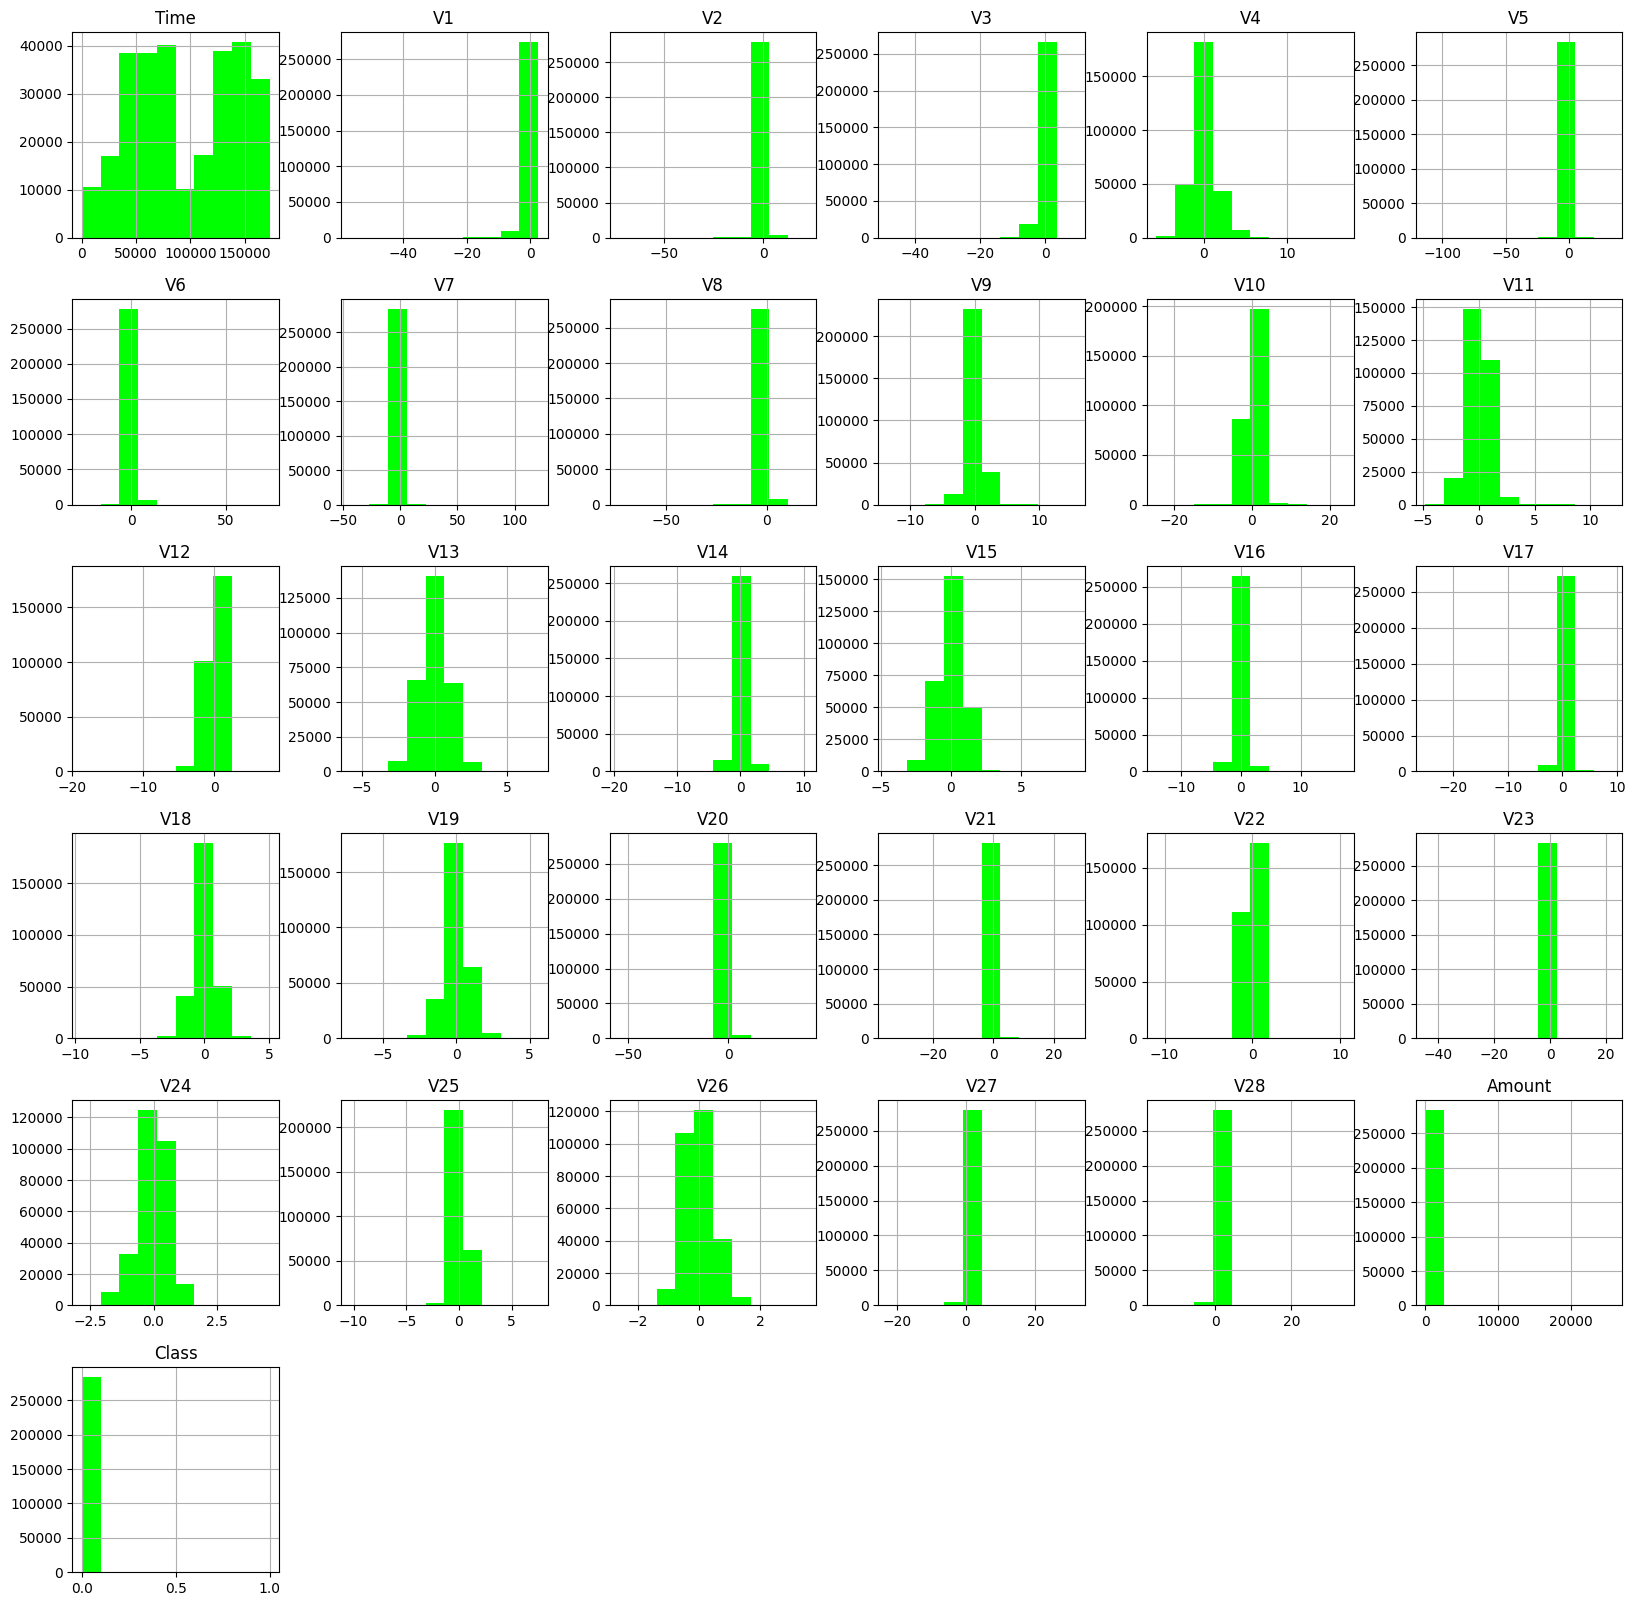

In [13]:
data.hist(figsize=(20,20), color='lime')
plt.show()

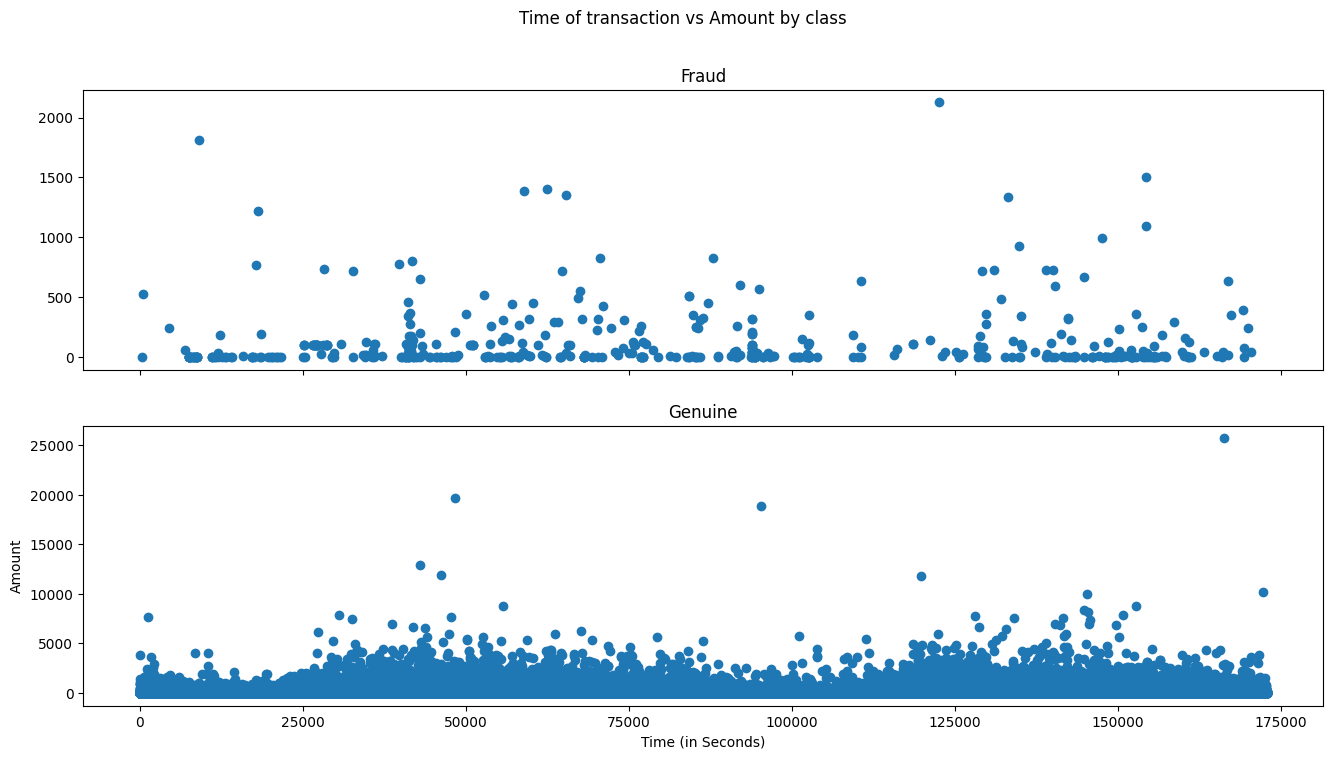

In [17]:


plt.rcParams['figure.figsize'] = (16, 8)

f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle('Time of transaction vs Amount by class')

ax1.scatter(fraud.Time, fraud.Amount)
ax1.set_title('Fraud')

ax2.scatter(genuine.Time, genuine.Amount)
ax2.set_title('Genuine')

plt.xlabel('Time (in Seconds)')
plt.ylabel('Amount')

plt.show()


<Axes: >

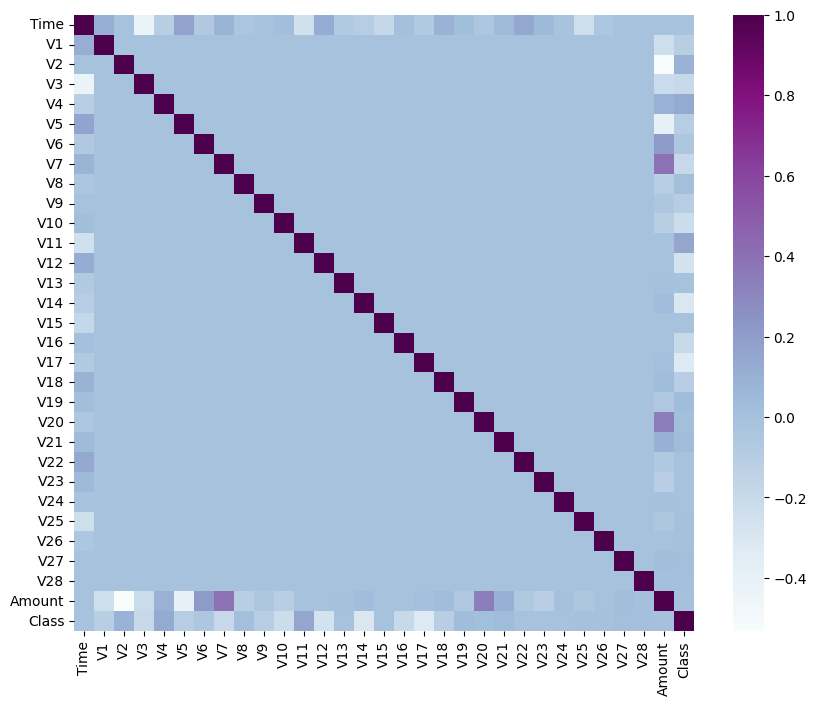

In [18]:
plt.figure(figsize=(10,8))
corr=data.corr()
sns.heatmap(corr,cmap='BuPu')

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Prepare features and target
X1 = data.drop(['Class'], axis=1)
y1 = data['Class']

# Split the dataset
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.3, random_state=123)

# Initialize and train the logistic regression model
lr = LogisticRegression()
model2 = lr.fit(X1_train, y1_train)




In [21]:
from sklearn.metrics import accuracy_score

# Make predictions
prediction2 = model2.predict(X1_test)

# Calculate accuracy
accuracy_score(y1_test, prediction2)


0.9990285921608558

In [26]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score  # NOTE: Accuracy is not ideal for regression tasks

# Prepare data
X2 = data.drop(['Class'], axis=1)
y2 = data['Class']

# Initialize the model
dt = DecisionTreeRegressor()

# Train-test split
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.3, random_state=123)

# Train the model
model3 = dt.fit(X2_train, y2_train)

# Make predictions
prediction3 = model3.predict(X2_test)
accuracy_score (y2_test, prediction3)


0.99916903666772